## Basics ##

In [1]:
import torch
import numpy as np


In [2]:
def get_probs(N_features, a):
  i = torch.arange(1.0, N_features+1.0)
  p = i ** (-a)
  p = p/p[0]
  return p

In [3]:
from torch.distributions import Uniform, Bernoulli
def generate_features(N_examples, N_features, p):
  a = Uniform(0.0, 1.0).sample((N_examples, N_features))
  m = Bernoulli(p).sample((N_examples, ))
  f = a * m
  return f

In [4]:
from torch import nn

In [5]:
class ToyModel(nn.Module):
    def __init__(self, N_features, N_d, I=None):
        super().__init__()
        self.W = nn.Parameter(torch.randn(N_d, N_features))
        self.b = nn.Parameter(torch.zeros(N_features))
        if I is None:
          I = torch.ones(N_features)
        self.I = I

    def forward(self, f):
        return torch.relu(f @ self.W.T @ self.W + self.b)

    def get_h(self, f):
      return f @ self.W.T

In [6]:
class VanillaSAE(nn.Module):
  def __init__(self, N_features, N_h):
        super().__init__()
        self.Wenc = nn.Parameter(torch.randn(N_features, N_h))
        self.benc = nn.Parameter(torch.zeros(N_features))
        self.Wdec = nn.Parameter(torch.randn(N_h, N_features))
        self.bdec = nn.Parameter(torch.zeros(N_h))

  def forward(self, h):
    z = self.encode(h)
    return z, self.decode(z)

  def encode(self, h):
     return torch.relu(h @ self.Wenc.T + self.benc)

  def decode(self, z):
    return z @ self.Wdec.T + self.bdec

In [7]:
from tqdm import tqdm

In [10]:
def train_TOY(model, steps, lr, p, batch):
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)  # optimizer сюда, так как lr часть обучения
  stat = []
  for si in tqdm(range(steps)):
    features = generate_features(batch, len(model.b), p)
    features_after = model(features)
    loss = ((model.I * (features - features_after)) ** 2).sum(dim=1).mean()
    stat.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  return model, stat

## Test from the paper ##

In [24]:
model_original = ToyModel(20, 5)
steps = 2 ** 14
res = train_TOY(model_original, steps, 0.001, get_probs(20, 0.7), 256)
stat = np.array(res[1])
W = model_original.W.detach()
Wcorr = W.T @ W

100%|██████████| 16384/16384 [00:27<00:00, 601.63it/s]


In [25]:
import matplotlib.pyplot as plt

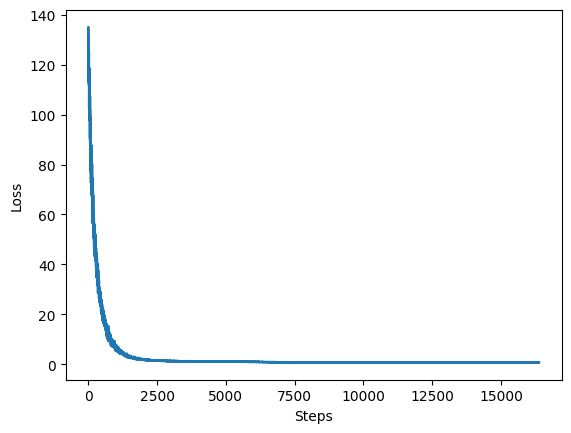

In [26]:
plt.plot(np.linspace(0, steps-1, steps), stat)
plt.ylabel('Loss')
plt.xlabel('Steps')
plt.show()

In [20]:
import seaborn as sns

<Axes: >

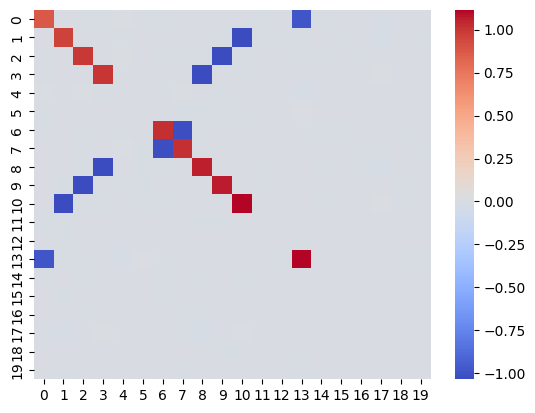

In [28]:
sns.heatmap(Wcorr, cmap='coolwarm')

## Different F and d ##

In [ ]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
Fs = [10, 15, 25, 30]
for i in range(4):
  F = Fs[i]
  model_original = ToyModel(F, 5)
  steps = 2 ** 14
  res = train_TOY(model_original, steps, 0.001, get_probs(F, 0.7), 256)
  stat = np.array(res[1])
  W = model_original.W.detach()
  Wcorr = W.T @ W

  sns.heatmap(Wcorr, ax=axes[i], cmap='coolwarm')
  axes[i].set_xlabel(f'F = {F}')
fig.show()

 39%|███▊      | 6341/16384 [00:09<00:13, 760.20it/s]

In [9]:
def train_SAE(model, expert, steps, lr, p, batch, lmbd):
  optimizer = torch.optim.Adam(model.parameters(), lr=lr)
  stat = []
  for si in tqdm(range(steps)):
    features = generate_features(batch, len(expert.b), p)
    with torch.no_grad():
      h = expert.get_h(features)
    z, h_res = model(h)
    loss = ((h - h_res) ** 2).sum(dim=1).mean() + (torch.abs(z)).sum(dim=1).mean() * lmbd
    stat.append(loss.item())
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
  return model, stat